In [1]:
import numpy as np
import pandas as pd
import pickle

from config import config
from xgboost import XGBClassifier
from matplotlib import pyplot as plt
from utils import (
    build_metadata, plot_class_distribution, split_metadata,
    print_split_summary, preprocess_img, sample_pixels,
    encode_labels, decode_labels, count_by_class, evaluate_split,
    get_feature_corr_ranking, extract_features, build_dataset
)

In [2]:
def process_pair(img_path, mask_path, train=False):
    img, mask, pixel_valid = preprocess_img(img_path, mask_path, train=train, ml='classic')
    features, feature_names = extract_features(img)

    if train:
        valid = pixel_valid & (mask != 0)
    else:
        valid = pixel_valid

    X = features[:, valid].T.astype(np.float32)
    y = mask[valid].reshape(-1).astype(np.uint8)
    return X, y, feature_names


def concatenate(results):
    X_parts = []
    y_parts = []
    feature_names = None

    for X, y, names in results:
        X_parts.append(X)
        y_parts.append(y)
        if feature_names is None:
            feature_names = names

    return np.concatenate(X_parts, axis=0), np.concatenate(y_parts, axis=0), feature_names

In [3]:
meta = build_metadata(config.DATA_DIR / 'samples')
train_meta, val_meta, test_meta = split_metadata(meta)

if min(len(val_meta), len(test_meta)) < 5:
    print(
        f"WARNING: split is only {len(train_meta)} train / {len(val_meta)} val / {len(test_meta)} test images. "
        "Metrics will be noisy and overfitting will look worse than it is; use more images or cross-validation."
    )

print_split_summary('train', train_meta)
print_split_summary('val', val_meta)
print_split_summary('test', test_meta)

Scanning masks:   0%|          | 0/559 [00:00<?, ?it/s]

Scanning masks: 100%|██████████| 559/559 [00:00<00:00, 612.50it/s]


[train] images: 447
  Unknown  pixels=  229,585 images=111
  Greenery pixels=8,257,143 images=268
  Sand     pixels=18,622,508 images=402
  Water    pixels=10,206,745 images=311
  Cement   pixels=9,019,840 images=304
  strata: {'base__w_0__c_0': 74, 'water_and_cement__w_gt_10k__c_gt_10k': 68, 'water_only__w_gt_10k__c_0': 65, 'water_and_cement__w_1k_10k__c_gt_10k': 60, 'cement_only__w_0__c_gt_10k': 36, 'water_and_cement__w_101_1k__c_gt_10k': 27, 'water_and_cement__w_gt_10k__c_1k_10k': 25, 'water_and_cement__w_1_100__c_gt_10k': 23, 'cement_only__w_0__c_1k_10k': 14, 'water_and_cement__w_gt_10k__c_101_1k': 10, 'cement_only__w_0__c_101_1k': 8, 'water_and_cement__w_101_1k__c_1k_10k': 7, 'water_and_cement__w_gt_10k__c_1_100': 6, 'water_and_cement__w_1_100__c_1k_10k': 6, 'cement_only__w_0__c_1_100': 4, 'water_and_cement__w_1k_10k__c_1k_10k': 4, 'water_and_cement': 3, 'water_and_cement__w_1k_10k__c_101_1k': 3, 'water_only__w_1k_10k__c_0': 2, 'water_only': 2}
[val] images: 56
  Unknown  pixels= 

In [4]:
print(train_meta.describe())

        total_pixels   has_water  has_cement    has_sand       count_0  \
count     447.000000  447.000000  447.000000  447.000000    447.000000   
mean   103659.554810    0.695749    0.680089    0.899329    513.612975   
std      2092.820939    0.460605    0.466964    0.301230   3225.735289   
min     98427.000000    0.000000    0.000000    0.000000      0.000000   
25%    102680.000000    0.000000    0.000000    1.000000      0.000000   
50%    104190.000000    1.000000    1.000000    1.000000      0.000000   
75%    105350.000000    1.000000    1.000000    1.000000      0.000000   
max    106304.000000    1.000000    1.000000    1.000000  48877.000000   

            count_1        count_2        count_3        count_4  
count    447.000000     447.000000     447.000000     447.000000  
mean   18472.355705   41661.091723   22833.881432   20178.612975  
std    29616.753112   40523.104703   35133.486729   26048.697072  
min        0.000000       0.000000       0.000000       0.000000 

In [5]:
print(train_meta.head())

               sample_id                                           img_path  \
0          LuxorEast_g12  data/samples/imgs/LuxorEast_g12_Spectral_300px...   
1          CairoUniv_g01  data/samples/imgs/CairoUniv_g01_Spectral_300px...   
2           AswanDam_g00  data/samples/imgs/AswanDam_g00_Spectral_300px.tif   
3  ZagazigFieldsEast_g10  data/samples/imgs/ZagazigFieldsEast_g10_Spectr...   
4       SafagaInland_g12  data/samples/imgs/SafagaInland_g12_Spectral_30...   

                                           mask_path  total_pixels  has_water  \
0    data/samples/masks/LuxorEast_g12_Mask_300px.tif        100233          1   
1    data/samples/masks/CairoUniv_g01_Mask_300px.tif        103845          0   
2     data/samples/masks/AswanDam_g00_Mask_300px.tif         98728          1   
3  data/samples/masks/ZagazigFieldsEast_g10_Mask_...        104748          1   
4  data/samples/masks/SafagaInland_g12_Mask_300px...        100835          1   

   has_cement  has_sand  count_0  coun

Building dataset: 100%|██████████| 56/56 [00:05<00:00, 10.67it/s]


Train full: (45989211, 51) {'Greenery': 8257084, 'Sand': 18622443, 'Water': 10089959, 'Cement': 9019725}
Val      : (5815947, 51) {'Unknown': 6911, 'Greenery': 1037356, 'Sand': 2386635, 'Water': 1146834, 'Cement': 1238211}
Test     : (5788241, 51) {'Unknown': 32852, 'Greenery': 1229080, 'Sand': 2372578, 'Water': 1149789, 'Cement': 1003942}
Greenery available=8,257,084 sampled=  550,000
Sand     available=18,622,443 sampled=  600,000
Water    available=10,089,959 sampled=  550,000
Cement   available=9,019,725 sampled=  650,000
Train sampled: (2350000, 51) {'Greenery': 550000, 'Sand': 600000, 'Water': 550000, 'Cement': 650000}
Val sampled  : (5815947, 51) {'Unknown': 6911, 'Greenery': 1037356, 'Sand': 2386635, 'Water': 1146834, 'Cement': 1238211}
Test sampled : (5788241, 51) {'Unknown': 32852, 'Greenery': 1229080, 'Sand': 2372578, 'Water': 1149789, 'Cement': 1003942}


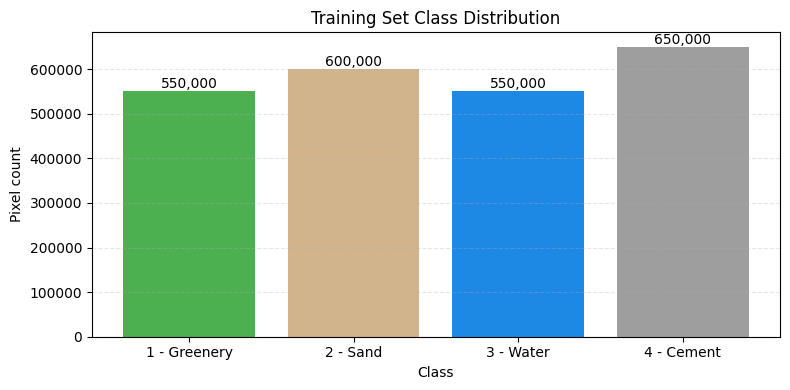

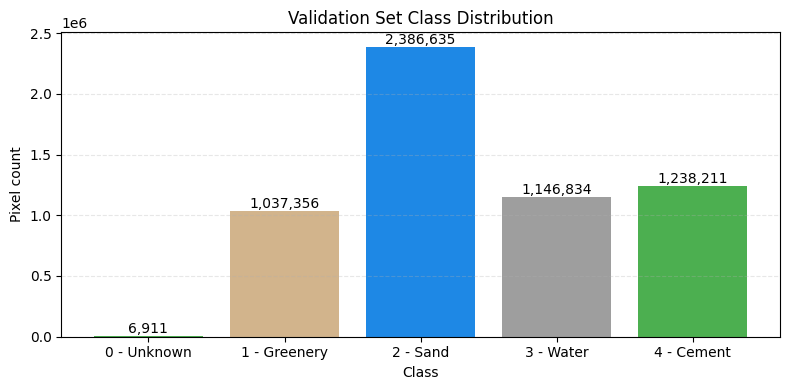

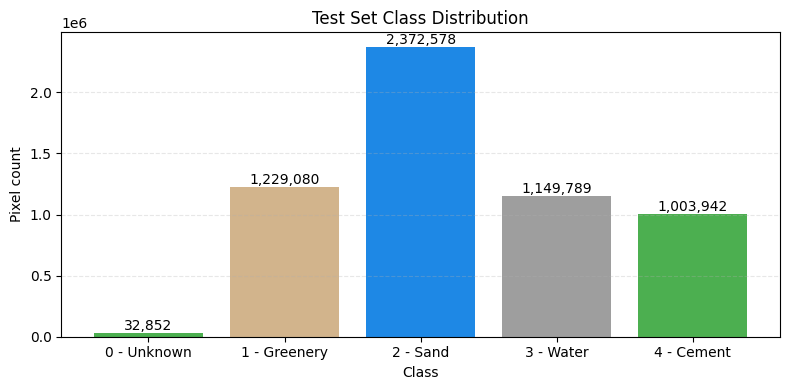

In [6]:
X_train_full, y_train_full, feature_names = build_dataset(train_meta, process_pair, concatenate, train=True)
X_val, y_val, _ = build_dataset(val_meta, process_pair, concatenate)
X_test, y_test, _ = build_dataset(test_meta, process_pair, concatenate)

print('Train full:', X_train_full.shape, count_by_class(y_train_full))
print('Val      :', X_val.shape, count_by_class(y_val))
print('Test     :', X_test.shape, count_by_class(y_test))

X_train, y_train, _ = sample_pixels(X_train_full, y_train_full, config.TRAIN_CAPS_CLASSIC)
print('Train sampled:', X_train.shape, count_by_class(y_train))
print('Val sampled  :', X_val.shape, count_by_class(y_val))
print('Test sampled :', X_test.shape, count_by_class(y_test))
plot_class_distribution(y_train, 'Training Set Class Distribution')
plot_class_distribution(y_val, 'Validation Set Class Distribution')
plot_class_distribution(y_test, 'Test Set Class Distribution')

In [7]:
sorted_features = get_feature_corr_ranking(X_train, y_train, feature_names)

for name, score in sorted_features:
    print(f"Feature: {name}, Correlation: {score:.4f}")

Feature: mndwi_mean_3, Correlation: 0.8512
Feature: mndwi, Correlation: 0.8350
Feature: awei_sh, Correlation: 0.8202
Feature: B10, Correlation: 0.8098
Feature: ndvi_mean_5, Correlation: 0.8068
Feature: swir_ratio, Correlation: 0.8044
Feature: B9, Correlation: 0.8041
Feature: nir_mean_3, Correlation: 0.7977
Feature: ndvi_mean_3, Correlation: 0.7974
Feature: B7, Correlation: 0.7888
Feature: B8, Correlation: 0.7887
Feature: ndvi, Correlation: 0.7825
Feature: savi, Correlation: 0.7758
Feature: msavi, Correlation: 0.7692
Feature: B6, Correlation: 0.7617
Feature: nbr, Correlation: 0.7531
Feature: bands_std, Correlation: 0.7513
Feature: visible_std, Correlation: 0.7465
Feature: ndwi, Correlation: 0.7456
Feature: gndvi, Correlation: 0.7456
Feature: B4, Correlation: 0.7354
Feature: B5, Correlation: 0.7317
Feature: B12, Correlation: 0.7262
Feature: awei_nsh, Correlation: 0.7253
Feature: red_blue_diff, Correlation: 0.7249
Feature: swir1_mean_3, Correlation: 0.7145
Feature: B11, Correlation: 0.712

In [8]:
y_train_enc = encode_labels(y_train)

model = XGBClassifier(
    n_estimators=900,
    max_depth=10,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    reg_alpha=0.1,
    reg_lambda=2.0,
    objective="multi:softprob",
    num_class=4,
    eval_metric="mlogloss",
    tree_method="hist",
    n_jobs=-1,
    random_state=config.RANDOM_STATE,
)

model.fit(X_train, y_train_enc)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

In [9]:
with open('model.pkl', 'wb') as f:
    pickle.dump(model, f)

In [10]:
model = pickle.load(open("model.pkl", "rb"))

===== Train =====
              precision    recall  f1-score   support

           1     0.9588    0.9640    0.9614    550000
           2     0.9703    0.9065    0.9373    600000
           3     0.9991    0.9987    0.9989    550000
           4     0.8936    0.9439    0.9180    650000

    accuracy                         0.9519   2350000
   macro avg     0.9554    0.9533    0.9539   2350000
weighted avg     0.9531    0.9519    0.9520   2350000

Confusion Matrix:
 [[530223    790    178  18809]
 [  1854 543871    147  54128]
 [   206    361 549280    153]
 [ 20740  15522    187 613551]]
mIoU: 0.9134718192502913
Per-class IoU: {'Greenery': 0.9256686452513967, 'Sand': 0.881943915170601, 'Water': 0.9977620832970036, 'Cement': 0.8485126332821641}


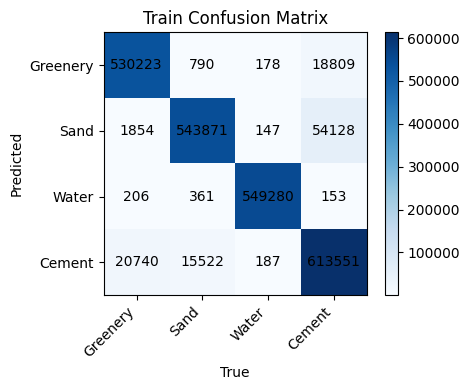

In [11]:
evaluate_split("Train", model, X_train, y_train)


===== Validation =====
              precision    recall  f1-score   support

           1     0.9211    0.9184    0.9197   1037356
           2     0.9689    0.8457    0.9031   2386635
           3     0.9270    0.9918    0.9583   1146834
           4     0.7656    0.9056    0.8297   1238211

    accuracy                         0.9003   5809036
   macro avg     0.8957    0.9154    0.9027   5809036
weighted avg     0.9088    0.9003    0.9013   5809036

Confusion Matrix:
 [[ 952664    8270    2037   74385]
 [  19002 2018336   84522  264775]
 [   3305    1815 1137470    4244]
 [  59246   54648    2996 1121321]]
mIoU: 0.8259347246068411
Per-class IoU: {'Greenery': 0.8514222336222159, 'Sand': 0.8233508799984335, 'Water': 0.9199936266013367, 'Cement': 0.7089721582053787}


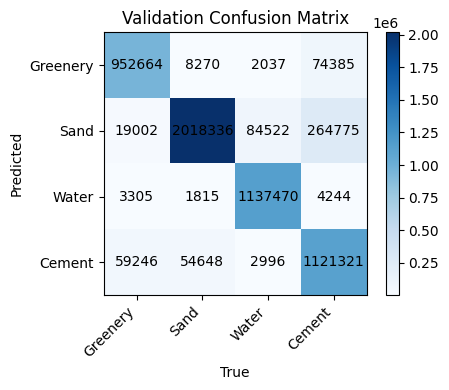

In [12]:
evaluate_split('Validation', model, X_val, y_val)

===== Test =====
              precision    recall  f1-score   support

           1     0.9363    0.9422    0.9392   1229080
           2     0.9769    0.8888    0.9308   2372578
           3     0.9761    0.9899    0.9830   1149789
           4     0.7587    0.9020    0.8242   1003942

    accuracy                         0.9227   5755389
   macro avg     0.9120    0.9308    0.9193   5755389
weighted avg     0.9300    0.9227    0.9244   5755389

Confusion Matrix:
 [[1158068    7496    2264   61252]
 [  18971 2108853   22353  222401]
 [   6626     558 1138197    4408]
 [  53235   41919    3216  905572]]
mIoU: 0.8558422238484686
Per-class IoU: {'Greenery': 0.8854326590779807, 'Sand': 0.8705092276695103, 'Water': 0.966521515392885, 'Cement': 0.7009054932534986}


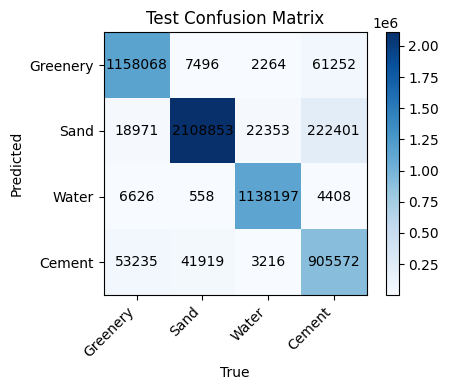

In [13]:
evaluate_split('Test', model, X_test, y_test)


In [14]:
importance_df = pd.DataFrame(
    {
        'feature': feature_names,
        'importance': model.feature_importances_,
    }
).sort_values('importance', ascending=False)

display(importance_df.head(20))

,feature,importance
24,awei_nsh,0.246817
36,red_blue_diff,0.147546
41,ndvi_mean_5,0.104823
8,B9,0.074844
11,B12,0.061771
44,mndwi_std_3,0.040314
3,B4,0.032194
18,gndvi,0.030812
42,ndvi_std_5,0.027664
49,swir1_mean_3,0.027371


In [15]:
@np.errstate(divide='ignore', invalid='ignore')
def show_prediction(model, split_df, idx=0):
    row = split_df.iloc[idx]
    img, mask, _ = preprocess_img(row['img_path'], row['mask_path'], ml='classic')
    features, _ = extract_features(img)

    X = features.reshape(features.shape[0], -1).T.astype(np.float32)
    pred_mask = decode_labels(model.predict(X)).reshape(mask.shape).astype(np.uint8)

    rgb = np.transpose(img[[3, 2, 1]], (1, 2, 0))
    rgb = np.clip(rgb * 3.0, 0, 1)

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(rgb)
    plt.title('RGB')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(mask, cmap='tab10', vmin=0, vmax=4)
    plt.title('Ground Truth')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(pred_mask, cmap='tab10', vmin=0, vmax=4)
    plt.title('Prediction')
    plt.axis('off')

    plt.show()

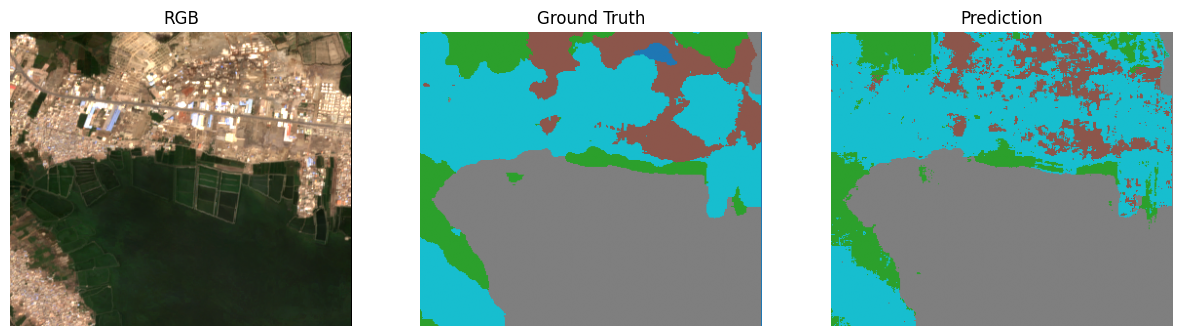

In [16]:
show_prediction(model, test_meta, idx=11)